# Phase 04 — Country Clustering

**Project:** Education and Income Inequality — A Cross-Country Panel Analysis
**Phase:** 04 — Country Clustering (Layer A: Descriptive)
**Date:** 2026-05-01
**Author:** Kota

---

## What this notebook does

This notebook builds a **data-driven typology of education-inequality regimes**
by clustering 167 countries on seven standardised development features.
It is the second analytical phase of the project (after Phase 03 EDA) and
the first phase that produces *new structural findings* rather than panel
diagnostics.

The Phase 03 EDA established that the analytical panel is dominated by a
*development gradient* — countries lie along a continuum from low- to
high-development states — and surfaced an income-faceted Kuznets-style
inverted-U in Gini. Phase 04 asks: **does a data-driven country typology
agree with this picture, or does it surface a different cut?**

The answer turns out to be: **it agrees, and quantifies it.** A K=3
clustering produces three regimes that map cleanly onto the Kuznets
narrative — a low-development group, a middle-development "Kuznets
transition" group, and a high-development "mature economies" group — with
the highest mean Gini found in the middle group, exactly as the inverted-U
prediction would have it.


## How to read this notebook

The notebook follows a **prose-led** structure with **three-layer
interpretation** for each figure and table:

- **Observation** — what the data shows
- **Explanation** — why the pattern arose (mechanism, structure, context)
- **Implication** — what it means for the project and portfolio narrative

Two adaptive design decisions are documented in PROJECT_LOG.md and
discussed inline in §4 below: (a) widening the aggregation window from
2015–2019 to 2010–2019 to retain China and other major LMICs; (b)
overriding the mechanical K-selection consensus from K=2 to K=3 on
substantive grounds.


## §2 Setup


In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
from IPython.display import Image, IFrame, display, Markdown

# Make src/ importable from notebook
sys.path.insert(0, str(Path('..').resolve()))
from src.paths import find_project_root

PROJECT_ROOT = find_project_root(Path('..').resolve())
DATA_DIR = PROJECT_ROOT / 'data' / 'processed'
TABLES_DIR = PROJECT_ROOT / 'outputs' / 'tables'

print(f"Project root: {PROJECT_ROOT}")

# Display options
pd.set_option('display.max_columns', 30)
pd.set_option('display.float_format', lambda x: f'{x:.3f}')


Project root: C:\Users\kotae\Documents\Portfolio\project\Project 4\education-inequality-analysis


## §3 Country-level feature matrix

Phase 04 clusters at the **country level**: each row is one country,
features aggregated across years. The aggregation is a `nanmean` over the
2010–2019 window (decision recorded in §4) on seven features chosen on
Phase 03 evidence:

- `mean_years_schooling` — Phase 03 strongest single linear predictor of
  Gini (r = −0.52)
- `log_gdp_per_capita_ppp` — log-transformed per Phase 03 skewness 1.87
- `enrol_secondary` — one of three nested enrolment variables; chosen as
  the most policy-relevant single representative
- `agri_value_added_gdp` / `manu_value_added_gdp` /
  `services_value_added_gdp` — sector composition trio, used jointly per
  Phase 03 finding #3 (VIF watch only on `agri`)
- `urban_population_pct` — structural development indicator

Excluded by design: `enrol_primary` (non-monotonic 100%-ceiling artefact),
`enrol_tertiary` and `enrol_secondary_female/male` (collinear with
`enrol_secondary`), `edu_expenditure_gdp` (null bivariate signal),
`gdp_per_capita_usd` (collinear with PPP), `inflation_cpi` (skewness 52),
`unemployment_rate` (1991-start ILO series), `population` (size, not
development).


In [2]:
features_raw = pd.read_csv(DATA_DIR / 'country_features.csv')
features_std = pd.read_csv(DATA_DIR / 'country_features_standardised.csv')

print(f"country_features.csv (raw scale, with NaN preserved):"
      f"  {features_raw.shape}")
print(f"country_features_standardised.csv (listwise-complete, z-scored):"
      f"  {features_std.shape}")
print(f"\nFeatures used for clustering ({features_std.shape[1] - 4}):")
for col in features_std.columns:
    if col not in ('iso3', 'country_name', 'region_name', 'income_level_name'):
        print(f"  - {col}")


country_features.csv (raw scale, with NaN preserved):  (217, 11)
country_features_standardised.csv (listwise-complete, z-scored):  (167, 11)

Features used for clustering (7):
  - mean_years_schooling
  - log_gdp_per_capita_ppp
  - enrol_secondary
  - agri_value_added_gdp
  - manu_value_added_gdp
  - services_value_added_gdp
  - urban_population_pct


## §4 Methodology and adaptive decisions

The Step 01 design fixed eight decisions before any clustering code was
written, including the feature set, the aggregation method, the
clustering algorithms (K-means + Ward hierarchical), the distance metric
(standardised Euclidean), the K-selection method (multi-diagnostic
consensus), and the missing-value policy (listwise). Two decisions were
later adapted in light of empirical findings:


### §4.1 Window adaptation: 2015–2019 → 2010–2019

The pre-registered fallback rule was *"use 2015–2019 unless listwise-complete
< 150, then widen to 2010–2019"*. The 2015–2019 run produced **155**
listwise-complete countries — passing the numerical threshold. But the
**62-country exclusion list** revealed that **China was dropped on
`enrol_secondary` alone**, alongside DZA, ZWE, NIC, GIN, COG, TJK, GMB, GUY,
LBR, PLW, SLB. A cross-country education-inequality typology that excludes
the world's largest middle-income country and a cluster of policy-relevant
LMICs cannot credibly speak to the Kuznets pattern flagged in Phase 03.

A diagnostic comparison (`scripts/phase04_diag_compare_windows.py`) showed
that widening to **2010–2019** rescues CHN plus 11 other LMICs at a count
of **167**. Wider windows (2005–2019 → 176; 2000–2019 → 178) rescue
marginal additional countries at the cost of averaging across major
structural ruptures (Iraq War aftermath, Libyan civil war, South Sudan
secession). 2010–2019 is the smallest widening that achieves the
qualitative goal.

**Recorded as PROJECT_LOG.md entry "## 2026-05-01 — Phase 04, Step 02b".**


### §4.2 K adaptation: mechanical K=2 → substantive K=3

The four-way K-selection diagnostic returned:

| Diagnostic        | Preferred K | Notes                                     |
|-------------------|------------:|-------------------------------------------|
| Elbow (WCSS)      | 3           | Only diagnostic supporting K = 3          |
| Silhouette        | 2           | 0.392 at K=2 vs 0.252 at K=3              |
| Calinski-Harabasz | 2           | 138 at K=2; monotonically decreasing      |
| Gap (1-SE rule)   | 4           | Margin 0.004 (fragile)                    |

The mechanical 2-of-4 consensus rule recommended K=2. But the structural
reading of the diagnostics — Gap monotonically rising from 0.96 to 1.25
over K=2..11, no plateau — is the textbook signature of a **continuous
distribution rather than separable clusters**. Silhouette and CH both
have a structural bias toward small K on continuous data: the cleanest
intra/inter split on a development gradient is the single bisection
(Global North vs Rest), which is exactly the K=2 result. They are not
independent evidence.

K=3 was adopted as primary on three substantive grounds: (1) Elbow
targets "how many regions meaningfully reduce within-cluster variance"
rather than "how separable are the clusters"; (2) Phase 03 finding #4
identifies three distinct Gini regimes (LIC noise / UMC peak / HIC
compressed), which K=3 is the smallest K to host; (3) K=4 coincides
numerically with the WB income classification's four bands, making the
finding circular. K=2 and K=4 are retained as robustness comparators.

**Recorded as PROJECT_LOG.md entry "## 2026-05-01 — Phase 04, Step 03b".**


### §4.3 Why this transparency matters

These two adaptations are not deviations to apologise for — they are the
evidence that the project balanced *pre-registration discipline* with
*data-driven judgement*. In each case the pre-registered numerical rule
passed (155 ≥ 150; mechanical 2-of-4 consensus identifies K=2), but
inspection of qualitative content (which countries are dropped; what the
cluster solution would mean) drove an explicit override that is logged
at the moment of the decision. A reviewer can follow the trail in
PROJECT_LOG.md and judge the override on its merits.


## §5 K selection diagnostics


In [3]:
diagnostics = pd.read_csv(TABLES_DIR / 'phase04_s03_k_diagnostics.csv')
display(diagnostics.style.format(precision=3).set_caption(
    'Per-K diagnostic scores'
))


,K,wcss,silhouette,calinski_harabasz,gap,gap_se
0,2,635.742,0.392,138.401,0.964,0.030
1,3,518.310,0.252,102.943,1.040,0.031
2,4,444.414,0.247,88.587,1.101,0.028
3,5,400.340,0.225,77.761,1.125,0.028
4,6,362.350,0.223,71.682,1.164,0.024
5,7,336.387,0.203,66.004,1.180,0.030
6,8,314.635,0.199,61.679,1.192,0.031
7,9,292.135,0.220,59.281,1.227,0.032
8,10,276.604,0.188,56.280,1.232,0.027


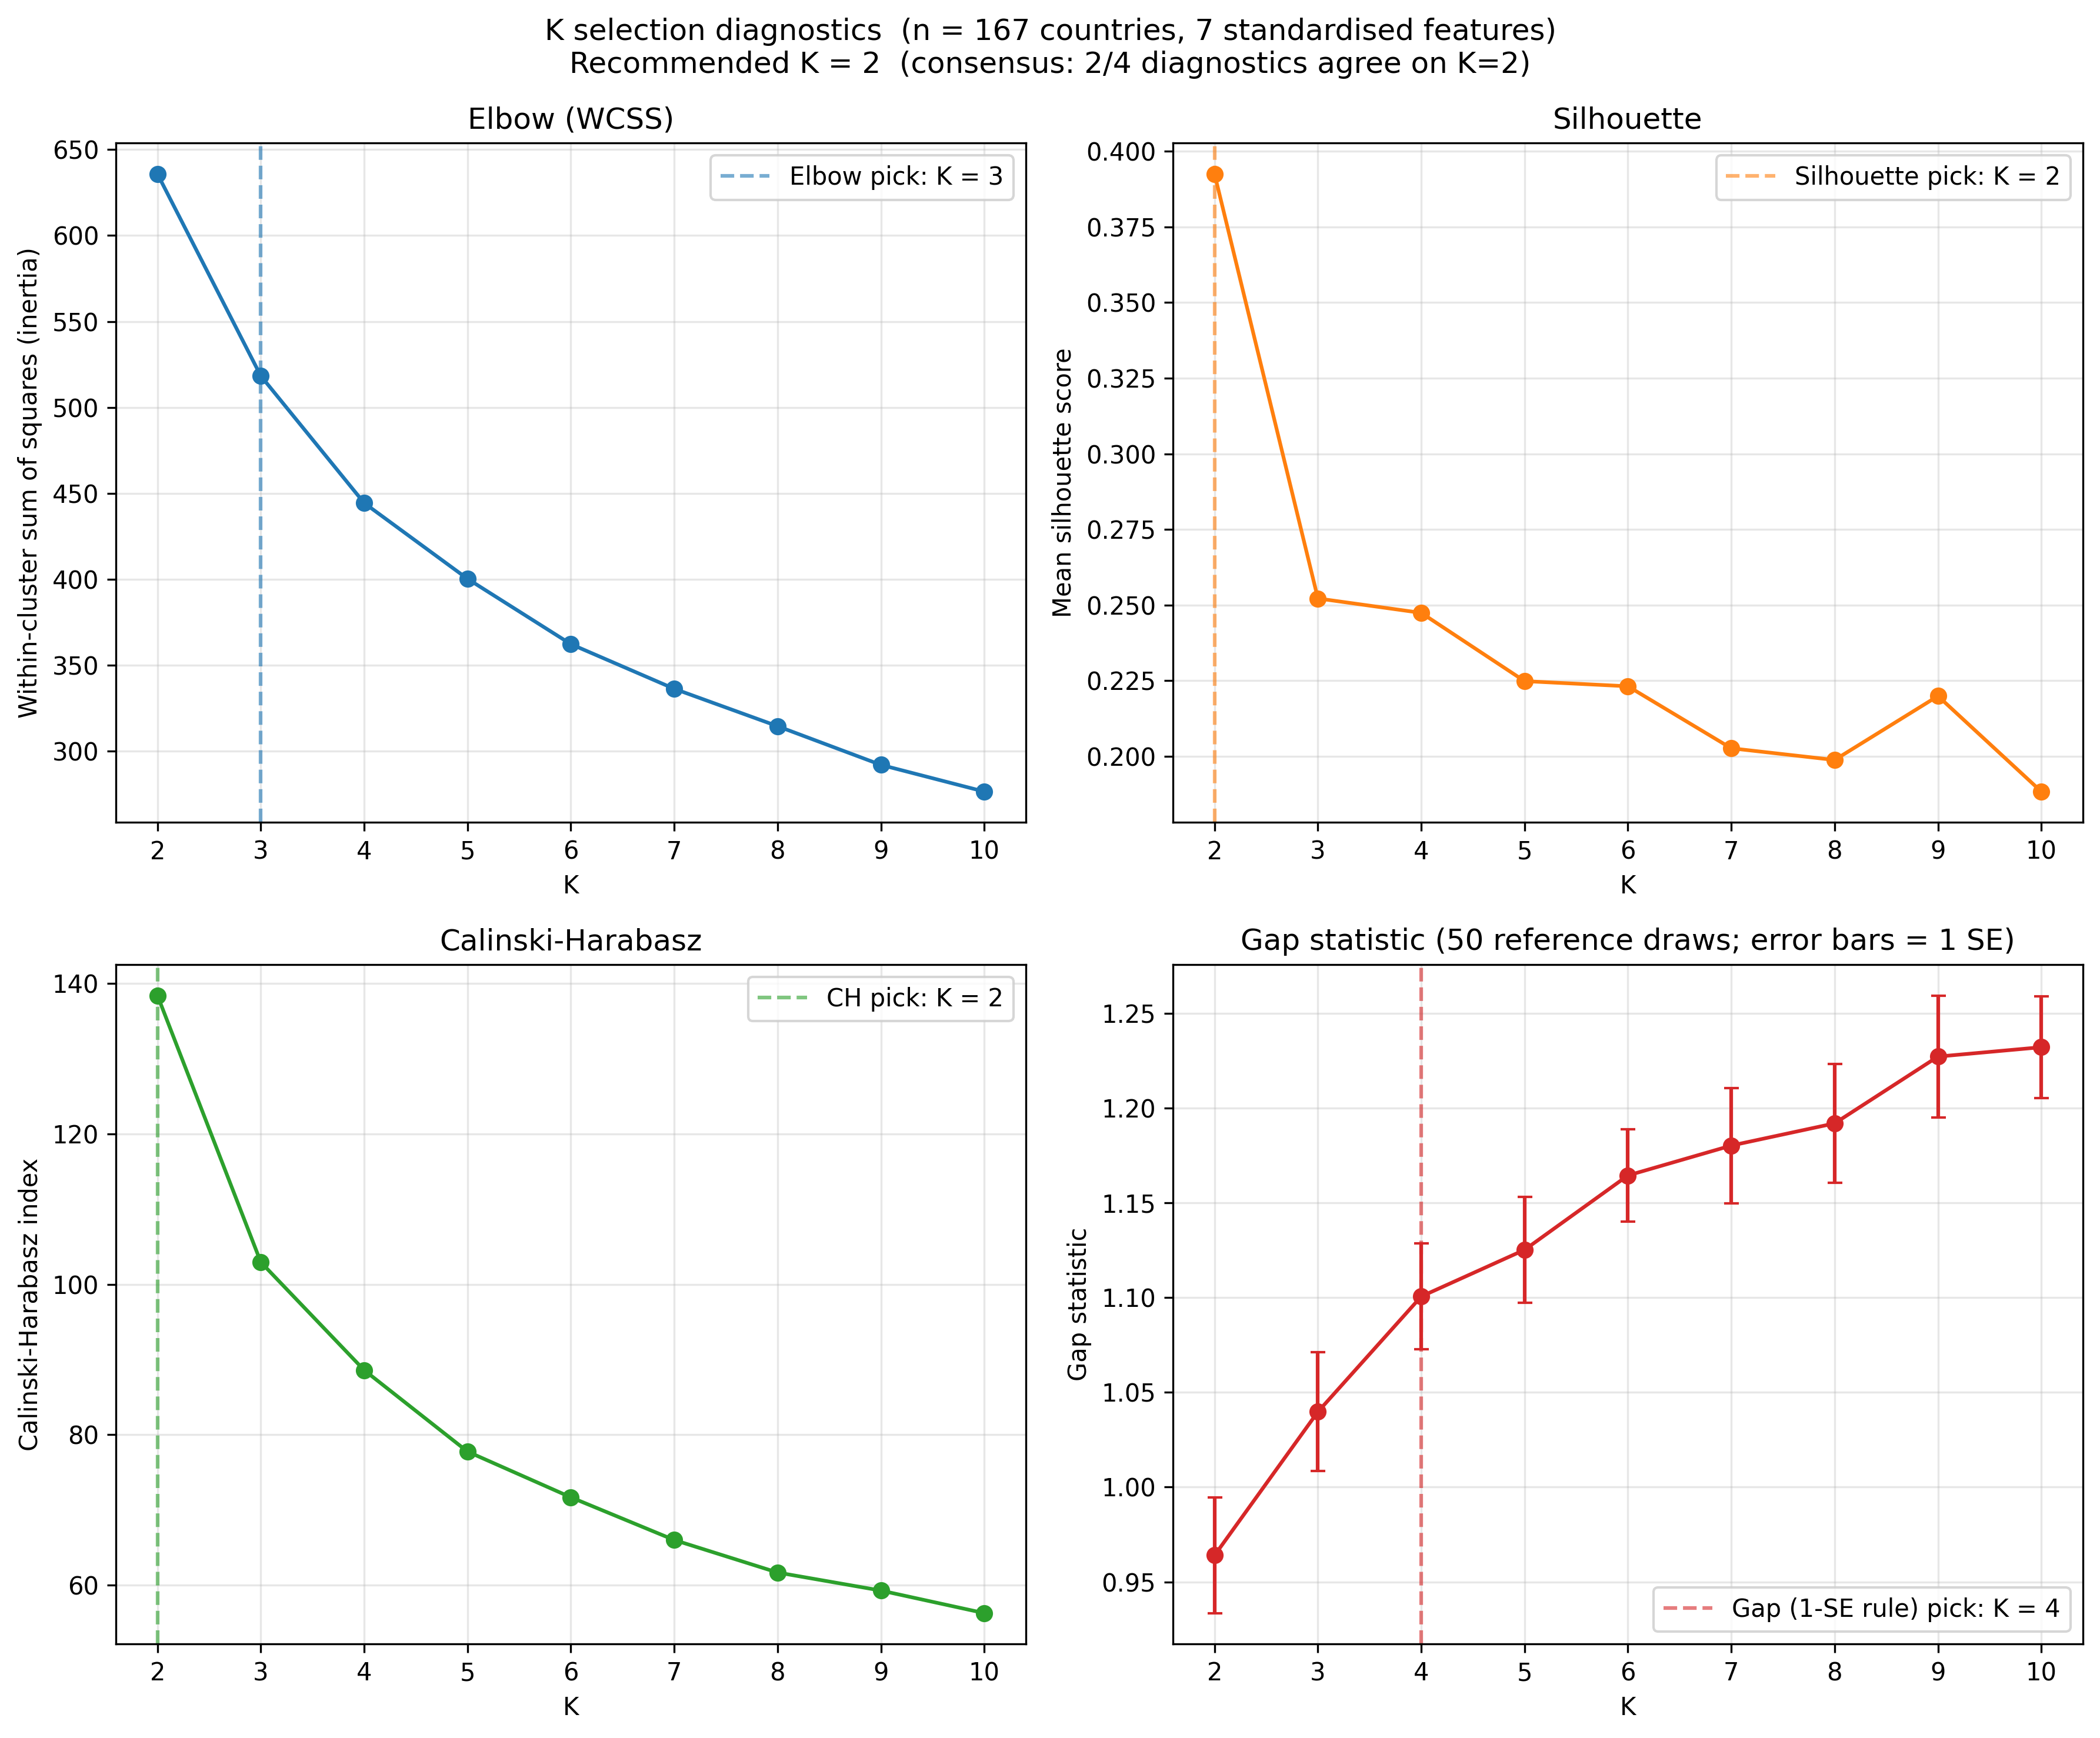

In [4]:
display(Image(filename='../outputs/figures/phase04_s03_k_selection.png'))


**Observation.** All four diagnostics computed cleanly over K=2..10. WCSS
falls smoothly without a sharp elbow; Silhouette peaks at K=2 (0.392) and
drops to 0.252 at K=3; Calinski-Harabasz monotonically decreases; Gap
statistic monotonically *increases* from 0.96 (K=2) to 1.25 (K=11) with
overlapping ±1 SE bands across consecutive K values.

**Explanation.** Two diagnostics (Silhouette, CH) have known biases
toward small K on continuous data: when a dataset lies along a gradient
rather than forming separable clouds, the cleanest "intra/inter" partition
is the single bisection, regardless of the substantive number of regimes
present. The gap statistic's monotone rise is the textbook indicator of a
gradient — there is no privileged K because every K continues to
"compress" the data better than the uniform null reference.

**Implication.** The mechanical 2/4 plurality (Silhouette + CH on K=2) is
not independent evidence; it is the same bias appearing twice. Elbow's
K=3 pick (the only diagnostic whose construction targets "K that
meaningfully reduces variance") is more informative for a
gradient-with-regimes setting. K=3 was therefore adopted as primary,
with K=2 and K=4 retained as robustness comparators (§6).


## §6 Cluster fitting and cross-algorithm robustness


In [5]:
from sklearn.metrics import silhouette_score, adjusted_rand_score

assignments = pd.read_csv(TABLES_DIR / 'phase04_s04_cluster_assignments.csv')

# Reload standardised features in the same row order as assignments
std = pd.read_csv(DATA_DIR / 'country_features_standardised.csv')
ordered = assignments[['iso3']].merge(std, on='iso3', how='left')
feature_cols = [c for c in std.columns
                if c not in ('iso3', 'country_name', 'region_name', 'income_level_name')]
X = ordered[feature_cols].values

# Cluster sizes per method
print("Cluster sizes:")
for col in ['cluster_kmeans_k2', 'cluster_kmeans_k3', 'cluster_kmeans_k4',
            'cluster_ward_k3']:
    sizes = assignments[col].value_counts().sort_index().to_dict()
    print(f"  {col:24s} : {sizes}")

# Silhouette scores
print("\nSilhouette scores (standardised Euclidean distance):")
for col in ['cluster_kmeans_k2', 'cluster_kmeans_k3', 'cluster_kmeans_k4',
            'cluster_ward_k3']:
    s = silhouette_score(X, assignments[col].values)
    primary = '  <-- PRIMARY' if col == 'cluster_kmeans_k3' else ''
    print(f"  {col:24s} : {s:.3f}{primary}")

# Cross-method agreement at K=3
ari = adjusted_rand_score(assignments['cluster_kmeans_k3'],
                          assignments['cluster_ward_k3'])
print(f"\nK-means K=3 vs Ward K=3 Adjusted Rand Index: {ari:.3f}")

# Confusion matrix
confusion = pd.crosstab(
    pd.Series(assignments['cluster_kmeans_k3'], name='K-means'),
    pd.Series(assignments['cluster_ward_k3'], name='Ward'),
)
print('\nConfusion matrix (K-means rows vs Ward cols):')
display(confusion)


Cluster sizes:
  cluster_kmeans_k2        : {0: 56, 1: 111}
  cluster_kmeans_k3        : {0: 40, 1: 59, 2: 68}
  cluster_kmeans_k4        : {0: 40, 1: 46, 2: 27, 3: 54}
  cluster_ward_k3          : {0: 46, 1: 37, 2: 84}

Silhouette scores (standardised Euclidean distance):
  cluster_kmeans_k2        : 0.392
  cluster_kmeans_k3        : 0.252  <-- PRIMARY
  cluster_kmeans_k4        : 0.247
  cluster_ward_k3          : 0.216

K-means K=3 vs Ward K=3 Adjusted Rand Index: 0.650

Confusion matrix (K-means rows vs Ward cols):


Ward,0,1,2
K-means,,,
0,40,0,0
1,6,37,16
2,0,0,68


**Observation.** K-means at K=3 produces clusters of sizes
**40 / 59 / 68**. Ward at K=3 produces **46 / 37 / 84** — broadly similar
shape but more lopsided. Cross-algorithm agreement at K=3 is
**ARI = 0.650**. The confusion matrix shows perfect alignment on
Cluster 0 (40/40 K-means → all Ward 0) and full nesting of K-means
Cluster 2 inside Ward Cluster 2 (68/68 K-means → all Ward 2). Disagreement
concentrates at the K-means Cluster 1 boundary, where Ward redistributes
22 countries to its Cluster 0 and 16 to its Cluster 2.

**Explanation.** ARI = 0.65 is the *substantial-agreement* range
(reference: Hubert and Arabie 1985 thresholds). The disagreement pattern
is structurally meaningful: the **extremes are robust, the middle is
fuzzy**. This is exactly the signature expected on a development
continuum — the lowest- and highest-development cluster cores are
unambiguous, while the Kuznets-transition zone is by definition the
intermediate state where countries are migrating from one regime to
another. Two algorithms drawing the boundary slightly differently is
honest geometry, not a fragile result.

**Implication.** K=3 survives as the primary deliverable. The
robustness number itself becomes part of the portfolio narrative:
"the middle is fuzzy because the middle is *literally a transition*".
K=3 vs K=4 ARI of 0.706 (computed in Step 04, not displayed above)
shows that K=4 mainly subdivides one of the K=3 clusters rather than
reorganising the structure — further support that K=3 is the
parsimonious natural granularity, not a perturbation artefact of
some other K.


## §7 Cluster profiles


### §7.1 Composition: who is in each cluster?


In [6]:
profiles = pd.read_csv(TABLES_DIR / 'phase04_s05_cluster_profiles.csv')

# Compose a compact composition table
composition_cols = ['cluster', 'label_proposed', 'n_countries']
income_cols = [c for c in profiles.columns if c.startswith('income_') and c.endswith('_n')]
region_cols = [c for c in profiles.columns if c.startswith('region_') and c.endswith('_n')]

display(
    profiles[composition_cols + income_cols].style.set_caption(
        'Cluster composition: income groups'
    )
)
display(
    profiles[composition_cols + region_cols].style.set_caption(
        'Cluster composition: WB regions (only columns with non-zero counts shown)'
    )
)


,cluster,label_proposed,n_countries,income_LIC_n,income_LMC_n,income_UMC_n,income_HIC_n,income_NC_n
0,0,Low-development / Sub-Saharan-led,40,16,23,0,0,1
1,1,Middle-development / Kuznets transition,59,0,19,38,2,0
2,2,High-development / mature economies,68,0,2,8,58,0


,cluster,label_proposed,n_countries,region_EAP_n,region_ECA_n,region_LAC_n,region_MENAAP_n,region_MENA_n,region_NA_n,region_SAS_n,region_SSA_n
0,0,Low-development / Sub-Saharan-led,40,7,0,0,2,0,0,4,27
1,1,Middle-development / Kuznets transition,59,11,14,17,6,0,0,2,9
2,2,High-development / mature economies,68,8,34,12,10,0,2,0,2


### §7.2 Feature profile: what are the clusters made of?


In [7]:
# Build a tidy feature-statistics table
feature_names = [
    'mean_years_schooling', 'log_gdp_per_capita_ppp', 'enrol_secondary',
    'agri_value_added_gdp', 'manu_value_added_gdp',
    'services_value_added_gdp', 'urban_population_pct',
]

rows = []
for _, prof in profiles.iterrows():
    row = {'cluster': int(prof['cluster']), 'label': prof['label_proposed']}
    for f in feature_names:
        row[f'{f}_mean'] = prof[f'{f}_mean']
    rows.append(row)

means_table = pd.DataFrame(rows)
display(means_table.style.format(precision=2).set_caption(
    'Cluster means on the 7 raw-scale features (transposed for reading)'
))

# Show GDP equivalent in dollars for readability
print("\nGDP per capita PPP (back-transformed from log mean):")
for _, prof in profiles.iterrows():
    c = int(prof['cluster'])
    log_gdp = prof['log_gdp_per_capita_ppp_mean']
    usd = np.exp(log_gdp)
    print(f"  Cluster {c}: log_mean = {log_gdp:.2f} -> ~${usd:>7,.0f} PPP")


,cluster,label,mean_years_schooling_mean,log_gdp_per_capita_ppp_mean,enrol_secondary_mean,agri_value_added_gdp_mean,manu_value_added_gdp_mean,services_value_added_gdp_mean,urban_population_pct_mean
0,0,Low-development / Sub-Saharan-led,4.22,8.09,46.06,23.65,9.90,46.45,35.25
1,1,Middle-development / Kuznets transition,8.85,9.37,85.18,9.87,13.01,53.78,54.54
2,2,High-development / mature economies,11.36,10.60,105.32,2.37,11.76,63.38,76.31



GDP per capita PPP (back-transformed from log mean):
  Cluster 0: log_mean = 8.09 -> ~$  3,246 PPP
  Cluster 1: log_mean = 9.37 -> ~$ 11,678 PPP
  Cluster 2: log_mean = 10.60 -> ~$ 40,223 PPP


### §7.3 Outcome: Gini distribution per cluster (descriptive)


In [8]:
gini_summary = profiles[
    ['cluster', 'label_proposed', 'gini_n',
     'gini_mean', 'gini_p25', 'gini_p50', 'gini_p75']
].rename(columns={'gini_p50': 'gini_median'})

display(gini_summary.style.format(precision=2).set_caption(
    'Country-level Gini means over 2010-2019, aggregated per cluster '
    '(descriptive only — Phase 05 owns the explanatory layer)'
))


,cluster,label_proposed,gini_n,gini_mean,gini_p25,gini_median,gini_p75
0,0,Low-development / Sub-Saharan-led,36,38.24,34.34,38.35,42.20
1,1,Middle-development / Kuznets transition,54,39.05,34.12,37.83,44.30
2,2,High-development / mature economies,53,34.72,30.39,33.11,36.56


**Observation.** The clusters arrange themselves into a textbook
development progression on every feature:

- `mean_years_schooling`: 4.22 → 8.85 → 11.36 (low / mid / high)
- `log_gdp_per_capita_ppp`: 8.09 → 9.37 → 10.60 ≈ $3.2K → $11.7K → $40.2K PPP
- `enrol_secondary`: 46.1% → 85.2% → 105.3% (>100% reflects gross enrolment ratio with adult and over-age learners)
- `urban_population_pct`: 35.3% → 54.5% → 76.3%

The sector composition shows the classic **Kuznets structural
transformation**:

- `agri_value_added_gdp`: 23.65% → 9.87% → 2.37% (monotone fall)
- `services_value_added_gdp`: 46.45% → 53.78% → 63.38% (monotone rise)
- `manu_value_added_gdp`: 9.90% → **13.01%** → 11.76% (peak in Cluster 1)

And the Gini outcome:

- Cluster 0: **38.24** (n=36/40)
- Cluster 1: **39.05** ← highest (n=54/59)
- Cluster 2: **34.72** (n=53/68)

**Explanation.** The data has independently re-discovered three findings
that the development economics literature would predict:

1. **Manufacturing peak in the middle group** is the textbook structural-
   transformation pattern: economies industrialise during their middle
   stage (China, Vietnam, Mexico, Turkey today; Korea and Taiwan a
   generation ago) before deindustrialising as services dominate the
   final stage.
2. **Highest Gini in the middle group** is the Kuznets prediction: the
   inverted-U claim is that inequality rises during structural transition
   and falls in mature economies. Phase 03 finding #4 surfaced this in
   raw income-faceted Gini time-series; Phase 04 reproduces it from a
   clustering that *did not use Gini as an input*.
3. **Cluster 0 Gini (38.24) close to Cluster 1 (39.05)** is the Kuznets
   left-arm: low-development economies are also unequal, just for
   different reasons (labour-market dualism, rural-urban gap). The 0.81
   gap between Clusters 0 and 1 is much smaller than the 4.33 gap from
   Cluster 1 to Cluster 2 — the inverted-U is asymmetric, with the
   compressed-Gini regime being more distinctive than the high-Gini
   plateau.

**Implication.** Phase 04 has produced its **headline portfolio finding**:
a data-driven typology, built on seven structural development indicators
*without using Gini as an input*, independently recovers the Kuznets
inverted-U pattern that Phase 03 surfaced from Gini time-series. This is
an unusually clean instance of "the same thing two different ways", and
will anchor the Phase 07 synthesis. The next two phases — Phase 05
econometric modelling and Phase 06 predictive modelling — can build on
this typology rather than start from scratch (e.g., cluster fixed effects
in Phase 05 robustness specifications).


## §8 Visualisations

Three figures complement the tables above. The PCA scatter shows where
each country sits in the cluster space; the Ward dendrogram shows the
hierarchical structure that justifies the K=3 cut; and the choropleth
shows the geographic distribution.


### §8.1 PCA scatter


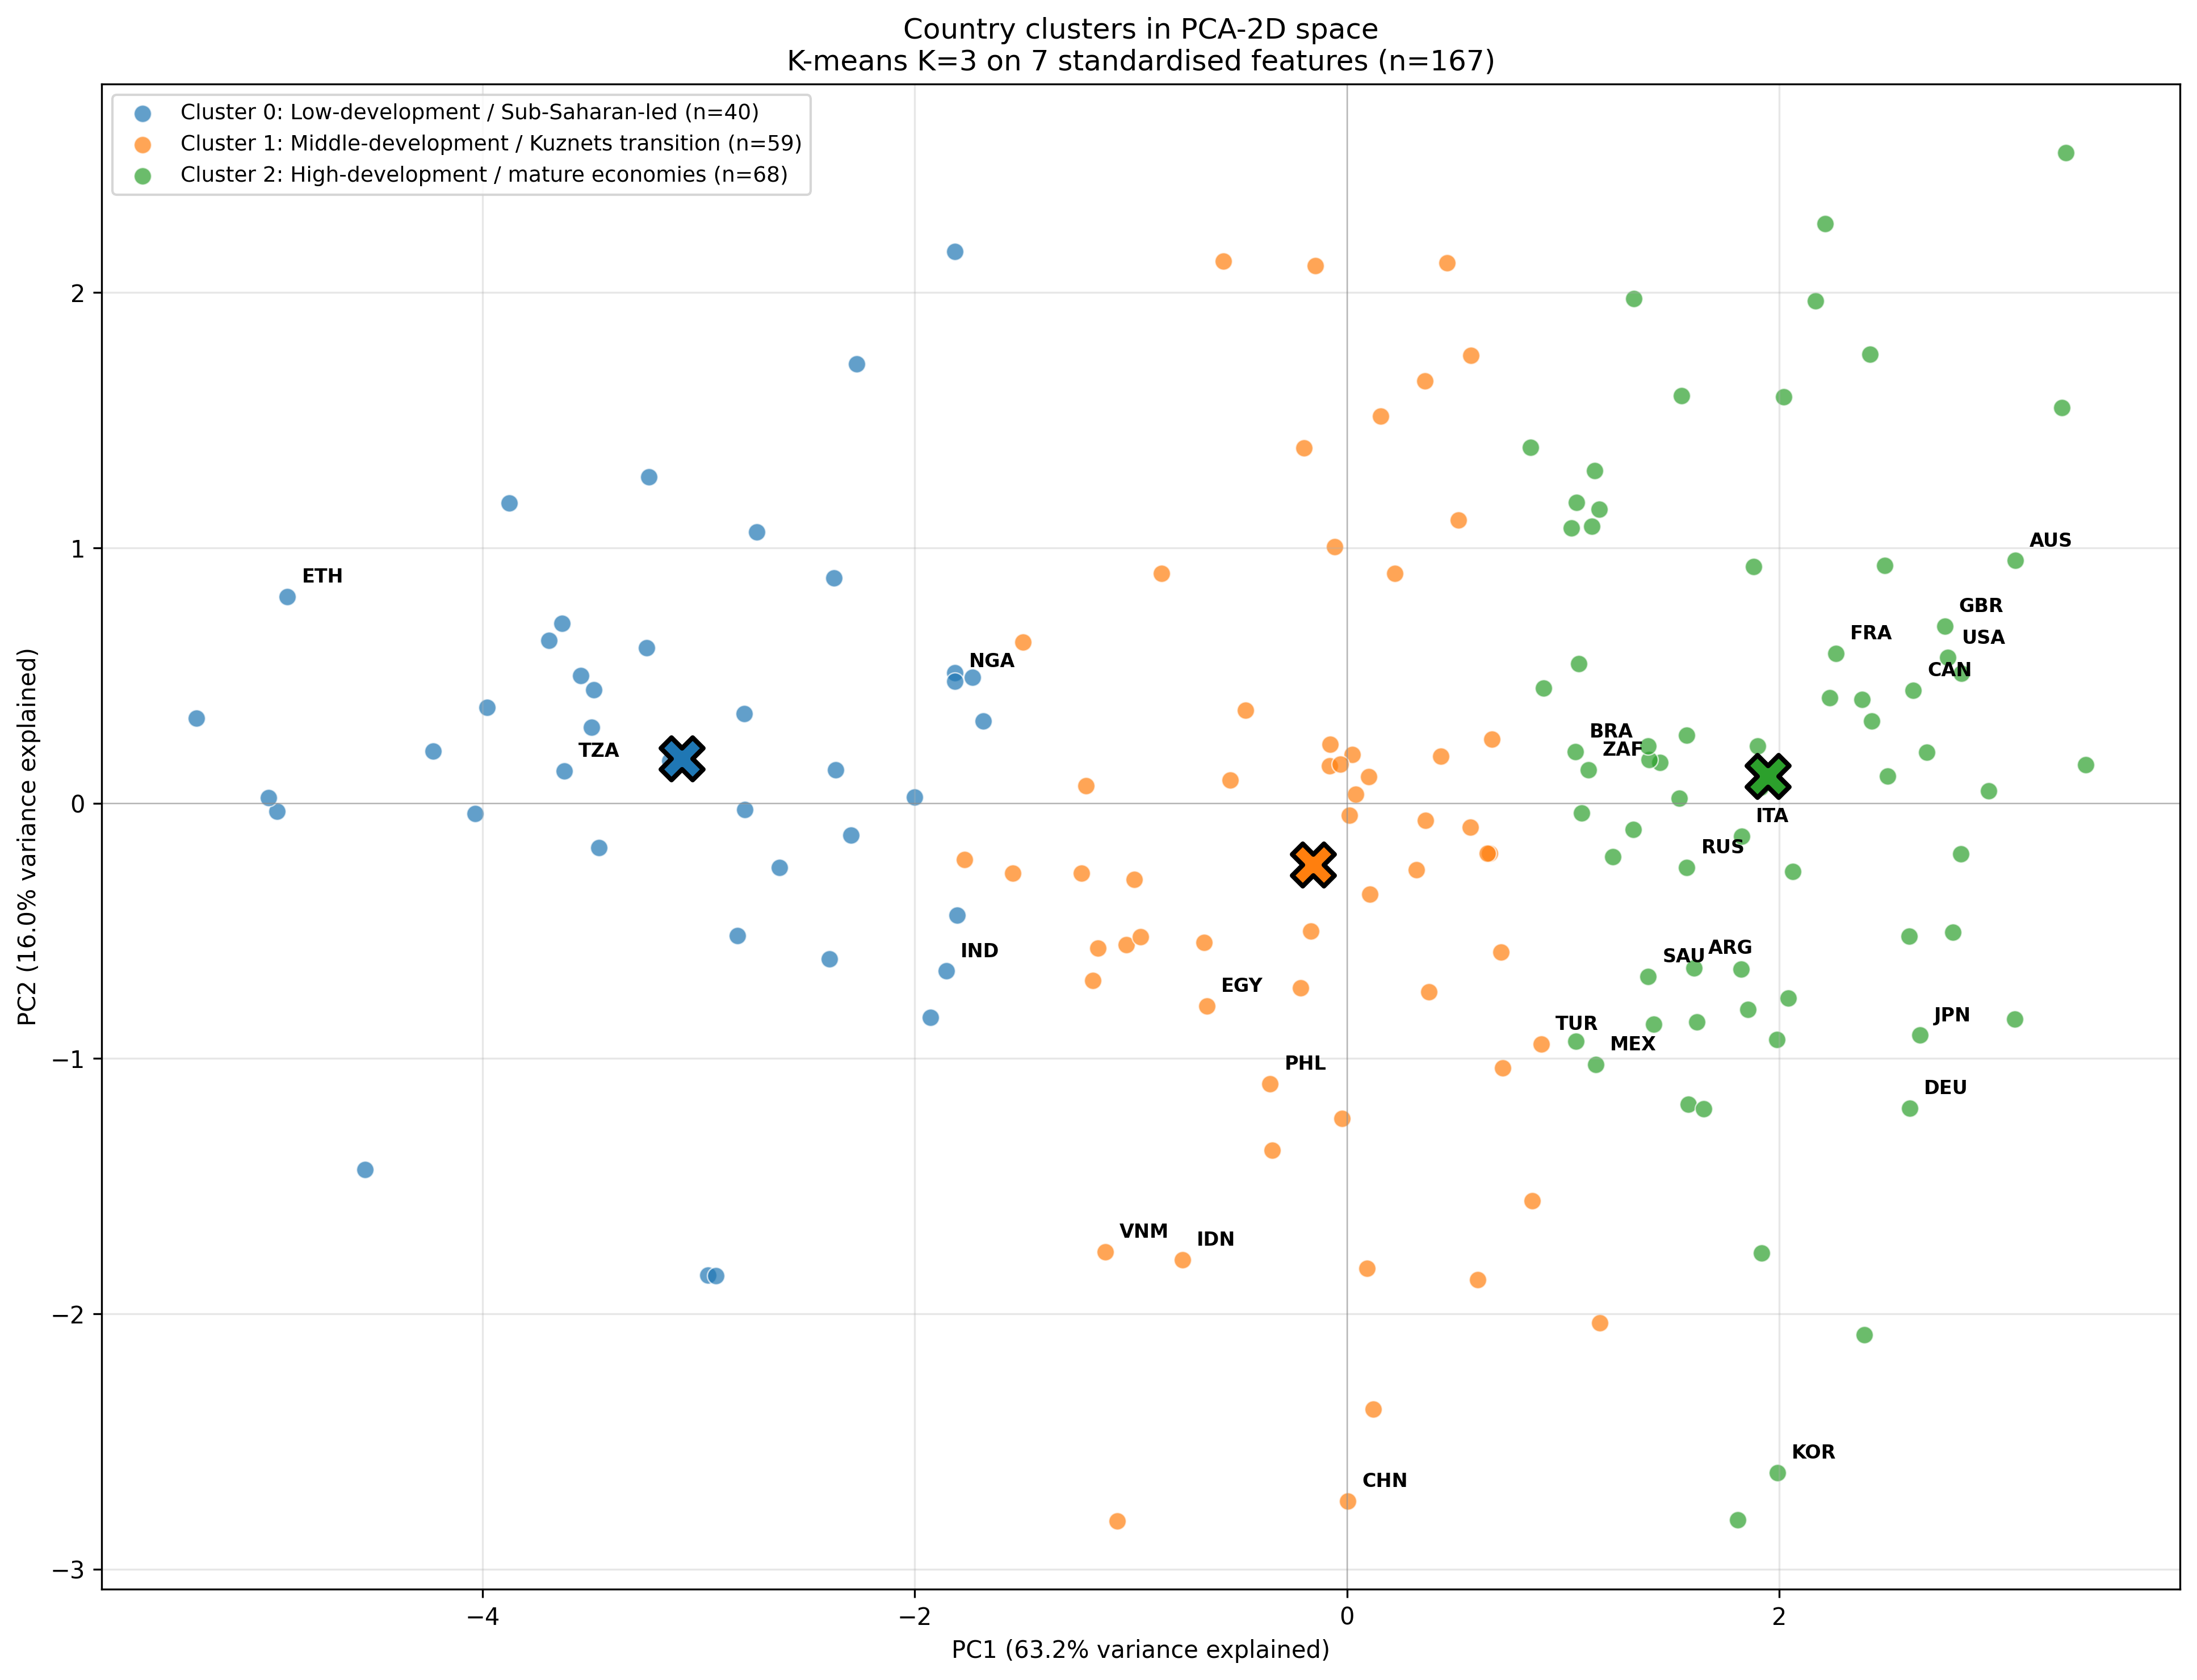

In [9]:
display(Image(filename='../outputs/figures/phase04_s06_pca_scatter.png'))


**Observation.** PC1 alone explains **63.2% of the variance**, and
PC1 + PC2 together explain **79.2%**. The three clusters separate cleanly
along PC1 (left: Cluster 0; centre: Cluster 1; right: Cluster 2) with
substantial overlap at the cluster boundaries. Watchlist annotations
place CHN near the centre of Cluster 1 (slightly low on PC2), IND in the
right of Cluster 0, and the major HICs (USA, JPN, DEU, GBR, FRA, CAN, AUS)
clustered tightly in the upper-right of Cluster 2. BRA, ZAF, MEX, ARG sit
at the **left edge of Cluster 2** — Cluster 2 by assignment but
positionally on the boundary with Cluster 1.

**Explanation.** A PC1 that captures 63% of variance in a 7-feature
space is unusually high (typical multivariate PCA distributes variance
more evenly). It indicates that the seven features are not seven
independent axes but seven *correlated indicators of a single underlying
dimension* — development. The boundary overlap, rather than being a
weakness, is the visual confirmation that the data is a continuum: there
is no clean topological gap between the clusters because there is no
gap in the underlying phenomenon. CHN's low PC2 reflects its higher
manufacturing share and lower services share than the typical
upper-middle-income country — China is *still industrialising* relative
to its income peers like Brazil and Mexico, which have already
transitioned to services-dominant economies.

**Implication.** "Development is approximately one-dimensional" is itself
a portfolio-strength claim, supported by PC1's 63% variance share. The
Latin American HIC anomaly (BRA, ZAF, MEX, ARG sitting at the Cluster
1/2 boundary) sets up the Phase 05 robustness analysis: any econometric
finding about the education-Gini relationship should be checked for
sensitivity to whether these countries are coded as "mature" or
"transitional".


### §8.2 Ward dendrogram


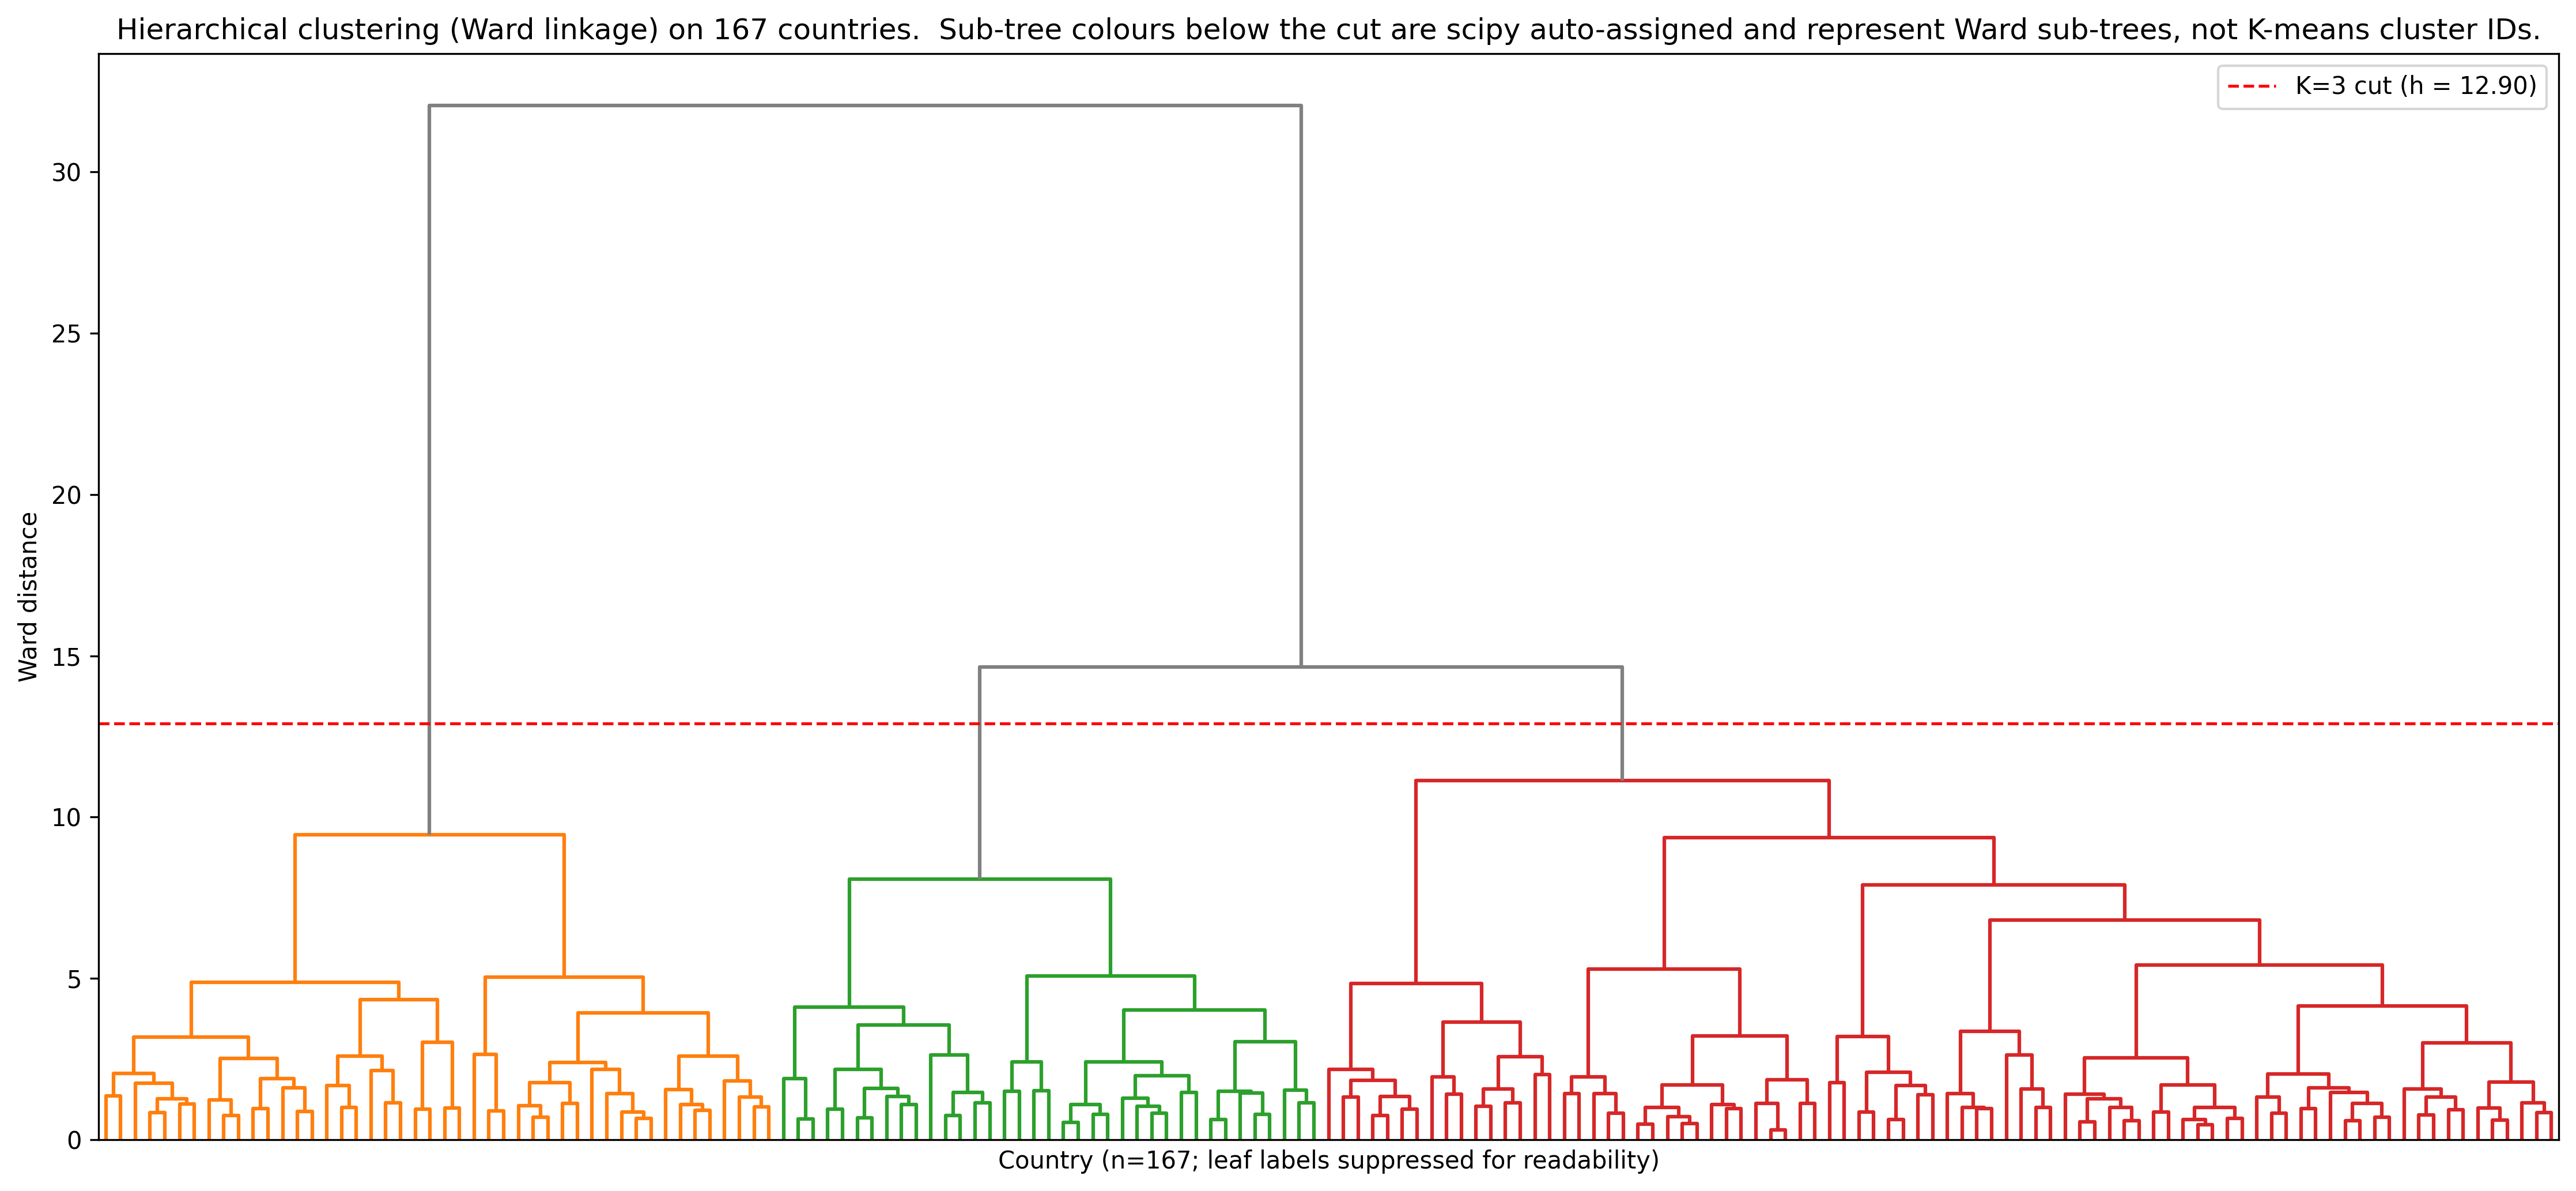

In [10]:
display(Image(filename='../outputs/figures/phase04_s06_dendrogram.png'))


**Observation.** The dendrogram shows a **dominant top split at Ward
distance ~32**, far above any other merge in the tree. The K=3 cut at
h=12.90 produces three sub-trees of ~50, ~35, ~80 leaves (the scipy
sub-tree colours are independent of the K-means cluster IDs and are
labelled in the figure caption).

**Explanation.** A dominant top split with a large height gap to the
next-highest merge is the structural justification for K=2 being a
mechanical Silhouette/CH winner: at h~32 the tree separates into two
maximally distinct halves. But the two halves are not equally internally
homogeneous: the right half (the larger, redder sub-tree) splits again
at h~14 into two further groups, while the left half (orange) does not.
This **asymmetric internal structure** is what K=3 captures and K=2
discards: the left half of the tree is a single coherent low-development
group, while the right half decomposes naturally into a transitional
group and a mature group.

**Implication.** The dendrogram is the cleanest visual argument for K=3
over K=2. It also makes Phase 03b's qualitative override of the
mechanical Silhouette/CH consensus visible as a structural reading of
the same data: the consensus saw the dominant top split; the override
recognised that one of the two halves has further structure that K=2
collapses.


### §8.3 Geographic choropleth

The interactive choropleth below colours each of the 167 included countries
by its K=3 K-means cluster. Hover over any country to see its full label,
WB region, WB income group, and 2010–2019 mean Gini. The 50 countries
dropped by the listwise filter (most WB-only territories, plus
conflict-affected states like SOM, SSD, SYR, YEM, VEN) appear blank.

If the embedded view below does not render in your environment, open
[`phase04_s06_choropleth_clusters.html`](../outputs/figures/phase04_s06_choropleth_clusters.html)
directly in a browser (the file is self-contained and works offline).


In [11]:
IFrame(
    src='../outputs/figures/phase04_s06_choropleth_clusters.html',
    width='100%', height=600,
)


**Observation.** The geographic distribution is highly coherent:

- **All of Sub-Saharan Africa** is Cluster 0 (blue).
- **South Asia (IND, BGD, NPL, etc.)** is Cluster 0.
- **China, Vietnam, Indonesia, Philippines** are Cluster 1 (orange).
- **Most of Latin America is Cluster 1** but BRA, ARG, CHL, MEX are
  Cluster 2 (green).
- **All of Europe, North America, Australia, Japan, Korea, Russia, plus
  Gulf HICs** are Cluster 2.

**Explanation.** The strong geographic coherence is a sign of cluster
quality — countries that are economically and structurally similar tend
to be geographic neighbours, so a typology that respects geography
without using geographic information as input is one that has captured
something real. The Latin American split — BRA/ARG/CHL/MEX in the mature
cluster vs PER/COL/ECU/etc. in the Kuznets cluster — is the most
interesting geographic pattern, because Latin America is the WB region
that Phase 03 finding #4 identified as having the highest mean Gini.

**Implication.** The choropleth is the most "shareable" Phase 04 artefact
(it works as a single image at a glance). It is also the artefact that
makes the **BRICS dispersion** finding immediately visible: CHN (orange),
IND (blue), BRA / ZAF / RUS (green) — the BRICS political grouping is
**not** structurally homogeneous in the education-inequality space.


## §9 Synthesis: nine takeaways

1. **K=3 is the data-driven granularity**, not a chosen-number-of-clusters
   default. Multi-diagnostic evidence + Ward robustness ARI 0.65 +
   substantive interpretation all converge on K=3.

2. **Development is approximately one-dimensional** in this 7-feature
   space: PC1 captures 63.2% of variance.

3. **The Kuznets inverted-U is reproduced from clustering**: Cluster 1
   (Kuznets transition) has the highest mean Gini (39.05), surpassing
   both Cluster 0 (38.24) and Cluster 2 (34.72). This is a same-finding-
   two-different-ways result with Phase 03 finding #4.

4. **Cluster 0 Gini ≈ Cluster 1 Gini**: the Kuznets curve is asymmetric.
   The compressed-Gini regime (Cluster 2) is more distinctive than the
   high-Gini plateau spanning Clusters 0 and 1.

5. **Structural transformation is textbook**: agri share falls
   monotonically (24% → 10% → 2%), services rise monotonically (46% →
   54% → 63%), and manufacturing **peaks in Cluster 1** (10% → 13% →
   12%). The data has rediscovered Kuznets's structural-transformation
   thesis from a clustering algorithm.

6. **CHN is in Cluster 1, the Kuznets-peak group.** Without the Step
   02b window-widening decision, CHN would have been dropped from the
   analysis on a single missing `enrol_secondary` value, and the
   middle cluster's identity as a Kuznets-transition group would
   have been substantively weaker.

7. **IND is in Cluster 0 with Sub-Saharan Africa**, structurally
   distinct from CHN despite both being South Asian / East Asian
   middle-income economies in a political sense. The data partition
   is **not the same as a regional partition**.

8. **Latin American HICs (BRA, MEX, ARG) plus ZAF sit at the
   Cluster 1/2 boundary**: these countries have completed enough of
   the development transition to belong with HICs but retain the
   high-inequality character of their region. Phase 05 robustness
   should treat their cluster assignment as borderline.

9. **BRICS is not a structural grouping**: BRA / ZAF in Cluster 2;
   CHN in Cluster 1; IND in Cluster 0; RUS in Cluster 2. The political
   acronym does not survive a structural cut on education and
   development.


## §10 Limitations

- **The 50 dropped countries are not random.** They concentrate among
  conflict-affected states (HTI, SOM, SSD, SYR, VEN, YEM), small WB-only
  territories, and a few persistent statistical-capacity cases (PRK,
  ZMB). These exclusions reinforce the MNAR concern noted in Phase 02
  Decision 3 and Phase 03 §Limitations.
- **Country-level aggregation flattens within-country heterogeneity.**
  A country like India, where states span Cluster-0 to Cluster-1 levels
  of development, is summarised as a single Cluster 0 row. This is a
  necessary simplification at the country-panel level of analysis but
  should be flagged in any policy-implication discussion.
- **The clustering uses 2010–2019 means**, so countries that have
  transitioned within the window (e.g. China during 2010–2019) are
  represented by an average of pre- and post-transition states. A
  trajectory analysis is out of scope for Phase 04 but is a natural
  Phase 05+ extension.
- **The clustering does not use Gini as an input.** This is a feature,
  not a bug — it is what allows Phase 04 to *re-discover* the Kuznets
  pattern rather than be tautological with it. But it means the cluster
  boundaries are not optimised for explaining inequality; some clusters
  may have wide internal Gini variation that an inequality-targeted
  partitioning would resolve.
- **Cluster labels are interpretive, not data-derived.** The
  "Low-development / Sub-Saharan-led" / "Middle-development / Kuznets
  transition" / "High-development / mature economies" labels are the
  authors' summary of the composition tables in §7. A reviewer who
  prefers different labels should look at §7 directly.
- **Causal claims are out of scope.** Phase 04 is the *descriptive*
  layer. Phase 05 (econometrics) and Phase 07 (synthesis) own causal
  reasoning, including the explicit boundary-setting on what cross-
  country observational panel data can and cannot establish.
